In [2]:
import dolfin
print("dolfin version:", dolfin.__version__)

dolfin version: 2019.1.0


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import time

from scipy.sparse import csr_matrix
from scipy.sparse import save_npz, load_npz

import os

from dolfin import *

In [16]:
from tqdm import tqdm  # pour les barres de progression dans les boucles

In [5]:
mesh_size = 200 
FE_type = "Lagrange"
degree = 2

mesh = UnitSquareMesh(mesh_size, mesh_size)
V = FunctionSpace(mesh, FE_type, degree)
print("Number of vertices:", mesh.num_vertices())

lines = {"mesh_size": mesh_size, "FE_type": FE_type, "degree": degree}
df_mesh_info = pd.DataFrame(lines, index=[0])

Number of vertices: 40401


In [6]:
# Boundary condition
class ConditionalBC(UserExpression):
    def eval(self, values, x):
        if x[0] < 0.1 and x[1] > 0.9:
            values[0] = 4.0
        elif x[1] < 0.1:
            values[0] = 1.0
        else:
            values[0] = 0.0
    def value_shape(self):
        return ()

u_D = ConditionalBC(degree=0)

def boundary(x, on_boundary):
    return on_boundary

bc = DirichletBC(V, u_D, boundary)

zero = Constant(0.0)
bc_zero = DirichletBC(V, zero, boundary)

# Define lifting
u_L = Function(V)
bc.apply(u_L.vector())  # fills u_L with the BC values

In [7]:
def heaviside(expr):
    return conditional(ge(expr, 0.0), 1.0, 0.0)

def get_conductivity(parameters):

    slope = parameters["slope"]; position = parameters["position"]; half_width = parameters["half_width"]; D_background = parameters["D_background"]; D_fracture = parameters["D_fracture"]
    x = SpatialCoordinate(mesh)
    x0 = x[0]
    x1 = x[1]

    norm_factor = Constant(100.0)


    arg1 = (position - half_width)/norm_factor - (slope/norm_factor * x0 + x1)
    arg2 = (slope/norm_factor * x0 + x1) - (position + half_width)/norm_factor
    arg3 = (slope/norm_factor * x0 + x1) - (position - half_width)/norm_factor
    arg4 = (position + half_width)/norm_factor - (slope/norm_factor * x0 + x1)

    K = D_background * (heaviside(arg1) + heaviside(arg2)) + D_fracture * heaviside(arg3) * heaviside(arg4)

    return K

In [8]:

def get_stiffness_and_load(parameters):
    K = get_conductivity(parameters)

    u = TrialFunction(V)
    v = TestFunction(V)

    a = inner(K*grad(u), grad(v))*dx
    L = Constant(0.0)*v*dx

    A = assemble(a)
    b = assemble(L)

    # Apply Dirichlet BCs to matrix and RHS vector
    b_mod = b.copy()
    A_uL = assemble(inner(K*grad(u_L), grad(v))*dx)
    b_mod.axpy(-1.0, A_uL)  # b_mod = b - A*u_L

    # Appliquer la BC homogène (u_0 = 0 sur bord)
    bc_zero.apply(A, b_mod)

    return A, b_mod

def PETSc_to_csr(A):
    """Convert a PETSc matrix to a SciPy CSR matrix."""

    # 1a) Grab the underlying PETSc Mat
    A_petsc = as_backend_type(A).mat()
    # 1b) Extract its CSR data (ai = row ptrs, aj = col inds, av = values)
    ai, aj, av = A_petsc.getValuesCSR()

    # 1c) Build a SciPy CSR matrix of the right shape
    n_rows, n_cols = A_petsc.getSize()
    A_csr = csr_matrix((av, aj, ai), shape=(n_rows, n_cols))

    return A_csr

def build_reduced_stiffness(A, V_r):
    A_csr = PETSc_to_csr(A)
    A_red = (V_r.T).dot(A_csr.dot(V_r))
    return A_red

def build_reduced_load(b, V_r):
    b_red = V_r.T.dot(b.get_local())
    return b_red

In [9]:
u_L_vect = np.array(u_L.vector().get_local())

In [10]:
example_parameters = {"slope": 40.0, "position": 70.0, "half_width": 5.0, "D_background": 100, "D_fracture": 1}
A_mu, b_mu = get_stiffness_and_load(example_parameters)
uh_HDM_sol = Function(V)
solve(A_mu, uh_HDM_sol.vector(), b_mu)
uh_HDM_sol_vec = np.array(uh_HDM_sol.vector().get_local()) + u_L_vect

In [11]:
uh_HDM_sol_vec.shape

(160801,)

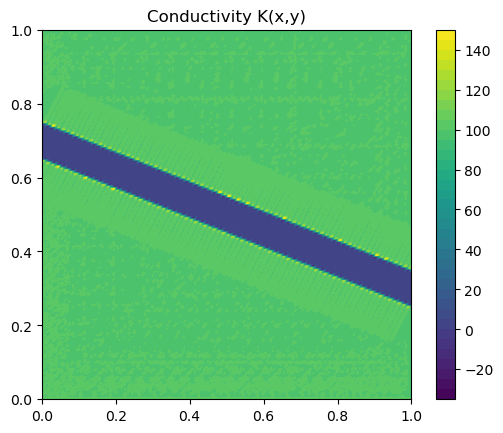

In [12]:
def plot_conductivity(parameters):
    K = get_conductivity(parameters)
    K_plot = project(K, V)

    p = plot(K_plot, cmap="viridis")
    plt.colorbar(p)
    plt.title("Conductivity K(x,y)")
    plt.show()

K_test = get_conductivity(example_parameters)
plot_conductivity(example_parameters)

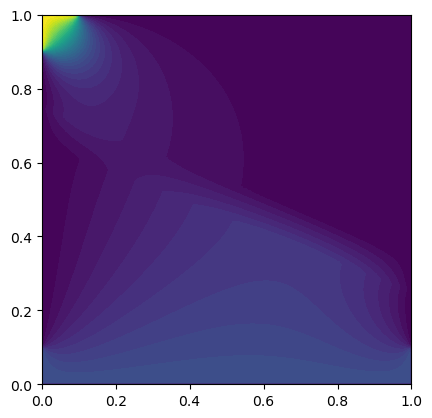

In [13]:
plot(uh_HDM_sol)

In [14]:
N_dof = V.dim()
Ns = 30
U_snapshot = np.zeros((N_dof, Ns))
print("dimension de U_snapshot:", U_snapshot.shape)

dimension de U_snapshot: (160801, 30)


In [17]:
parameters_list = []
for i in tqdm(range(Ns), desc="Génération des Snapshots"):
    slope = np.random.uniform(20.0, 60.0)
    position = np.random.uniform(50.0, 90.0)
    half_width = np.random.uniform(3.0, 7.0)
    D_background = np.random.uniform(80.0, 120.0)
    D_fracture = np.random.uniform(0.5, 2.0)

    parameters = {"slope": slope, "position": position, "half_width": half_width, "D_background": D_background, "D_fracture": D_fracture}
    parameters_list.append(parameters)

    A_mu, b_mu = get_stiffness_and_load(parameters)
    uh_HDM_sol = Function(V)
    solve(A_mu, uh_HDM_sol.vector(), b_mu)
    uh_HDM_sol_vec = np.array(uh_HDM_sol.vector().get_local()) + u_L_vect
    U_snapshot[:, i] = uh_HDM_sol_vec
print(parameters_list)

Génération des Snapshots:   0%|          | 0/30 [00:00<?, ?it/s]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:   3%|▎         | 1/30 [00:05<02:32,  5.27s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:   7%|▋         | 2/30 [00:09<02:06,  4.50s/it]

...

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:  97%|█████████▋| 29/30 [02:09<00:04,  4.59s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots: 100%|██████████| 30/30 [02:14<00:00,  4.47s/it]

[{'slope': 46.98339339592181, 'position': 61.83059158552451, 'half_width': 3.8002431695221106, 'D_background': 104.90647969231678, 'D_fracture': 1.2040490154129573}, {'slope': 58.656819901814956, 'position': 88.1711991042506, 'half_width': 6.753115410007116, 'D_background': 91.44132192195572, 'D_fracture': 0.9724001058180239}, {'slope': 46.66371171975217, 'position': 61.94809276572508, 'half_width': 4.575248281634535, 'D_background': 85.86567580906328, 'D_fracture': 0.5302584043789215}, {'slope': 44.38583370742742, 'position': 76.81604114737772, 'half_width': 6.858659621748318, 'D_background': 92.65366873339197, 'D_fracture': 1.2834859763269826}, {'slope': 41.32613979686208, 'position': 82.66985161415676, 'half_width': 6.300247139973457, 'D_background': 111.82352846756504, 'D_fracture': 1.5877651447897503}, {'slope': 25.810202718208537, 'position': 87.34559358831376, 'half_width': 5.414192315888368, 'D_background': 117.9197021617793, 'D_fracture': 1.7841013293431}, {'slope': 42.3587678

In [18]:
def numpy_to_fenics(numpy_vec, V, u_L_vect):
    """
    Reconstruit un objet Function FEniCS à partir d'un vecteur Numpy.
    """
    # 1. On crée une "boîte" FEniCS vide sur ton maillage V
    u_reconstruit = Function(V)
    
    # 2. On fait l'opération inverse mathématiquement (- au lieu de +)
    valeurs_internes = numpy_vec - u_L_vect
    
    # 3. On injecte le tableau numpy dans le vecteur FEniCS (l'inverse de get_local)
    u_reconstruit.vector().set_local(valeurs_internes)
    
    return u_reconstruit

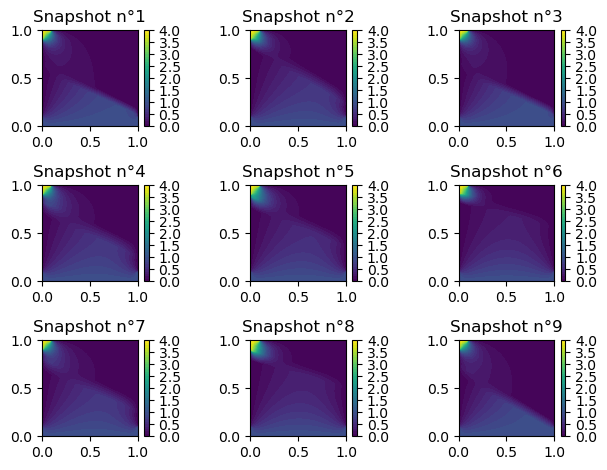

In [19]:
for i in range(9):
    vecteur_numpy = U_snapshot[:, i]    
    u_fenics = numpy_to_fenics(vecteur_numpy, V, u_L_vect)
    plt.subplot(3, 3, i + 1)
    p = plot(u_fenics)
    plt.title(f"Snapshot n°{i+1}")
    plt.colorbar(p, fraction=0.046, pad=0.04) 
plt.tight_layout()
plt.show()

In [43]:
U, S, Vt = np.linalg.svd(U_snapshot, full_matrices=False)



number of singular values: 30
U shape: (30, 30)
S shape: (30,)
Vt shape: (160801, 30)
Singular values: [1.19421921e+03 1.30410345e+02 1.12593210e+02 6.79021660e+01
 4.01956158e+01 3.81627188e+01 2.90481535e+01 2.84862111e+01
 1.98556924e+01 1.65341113e+01 1.52243657e+01 1.46005563e+01
 1.20404131e+01 1.00508627e+01 9.22700585e+00 7.66102826e+00
 6.50400894e+00 5.62670010e+00 4.95676300e+00 4.61115106e+00
 4.35358709e+00 3.63145813e+00 3.28409125e+00 2.91749334e+00
 2.76799967e+00 2.61761717e+00 2.41692300e+00 1.95572023e+00
 1.63696598e+00 1.04824521e+00]


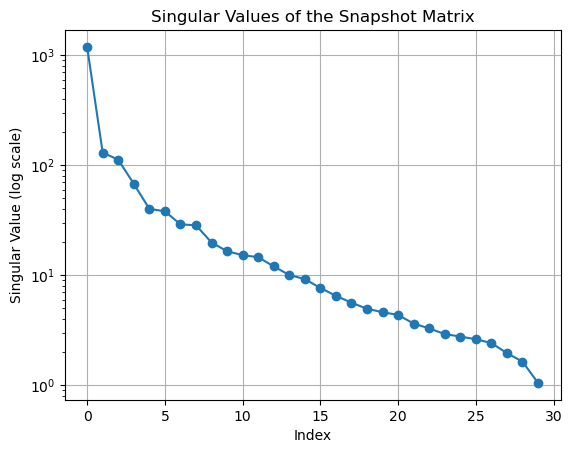

In [21]:
print("number of singular values:", len(S))
print("U shape:", U.shape)
print("S shape:", S.shape)
print("Vt shape:", Vt.shape)
print("Singular values:", S)
plt.semilogy(S, marker='o')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of the Snapshot Matrix')
plt.grid()
plt.show()

## Un premier test

Time for ROM solve: 0.25035691261291504 seconds
Time for full HDM solve: 2.1567790508270264 seconds


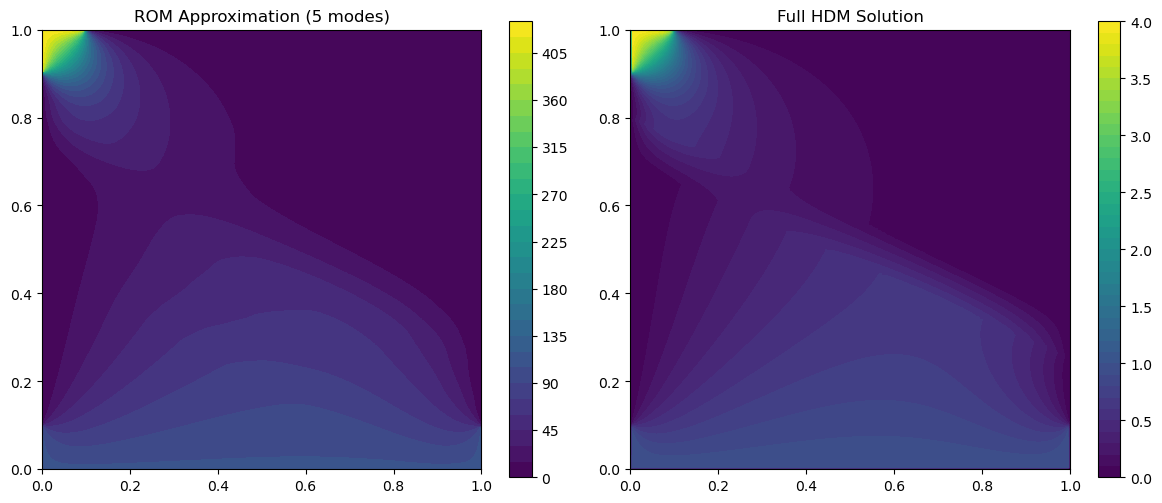

In [44]:
test_parameters = {"slope": 45.0, "position": 75.0, "half_width": 5.0, "D_background": 100.0, "D_fracture": 1.0}
t = time()
A_test, b_test = get_stiffness_and_load(test_parameters)
V_r = U[:, :5]  # les 5 premiers modes
A_red = build_reduced_stiffness(A_test, V_r)
b_red = build_reduced_load(b_test, V_r)
u_red = np.linalg.solve(A_red, b_red)
u_approx = V_r.dot(u_red) + u_L_vect
u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
print("Time for ROM solve:", time() - t, "seconds")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
p1 = plot(u_approx_fenics, cmap="viridis")
plt.colorbar(p1)
plt.title("ROM Approximation (5 modes)")
plt.subplot(1, 2, 2)
t = time()
A_full, b_full = get_stiffness_and_load(test_parameters)
u_full = Function(V)
solve(A_full, u_full.vector(), b_full)
u_full_vec = np.array(u_full.vector().get_local()) + u_L_vect
u_full_fenics = numpy_to_fenics(u_full_vec, V, u_L_vect)
print("Time for full HDM solve:", time() - t, "seconds")
p2 = plot(u_full_fenics, cmap="viridis")
plt.colorbar(p2)
plt.title("Full HDM Solution")
plt.tight_layout()
plt.show()

## Qui est V1 ?

les colones de U sont les modes POD, on les multiplie par 1000 pour mieux les visualiser


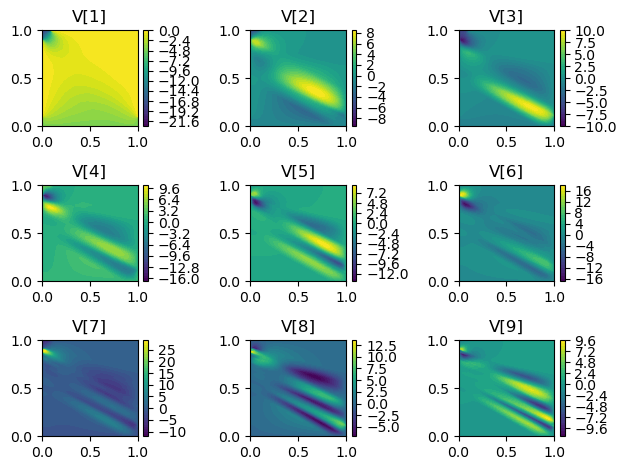

In [46]:
print("les colones de U sont les modes POD, on les multiplie par 1000 pour mieux les visualiser")
for i in range(9):
    vecteur_numpy = U[:, i]*1000
    u_fenics = numpy_to_fenics(vecteur_numpy, V, u_L_vect)
    plt.subplot(3, 3, i + 1)
    p = plot(u_fenics)
    plt.title(f"V[{i+1}]")
    plt.colorbar(p, fraction=0.046, pad=0.04) 
plt.tight_layout()
plt.show()

In [47]:
def error_L2(u1, u2):
    """Calcule l'erreur relative L2 entre deux fonctions FEniCS."""
    diff = Function(V)
    diff.vector()[:] = u1.vector().get_local() - u2.vector().get_local()
    return norm(diff, 'L2') / norm(u1, 'L2')

Error with 1 modes: 9.5045e+01
Error with 2 modes: 9.5152e+01
Error with 3 modes: 9.5448e+01
Error with 4 modes: 1.0657e+02
Error with 5 modes: 1.0658e+02


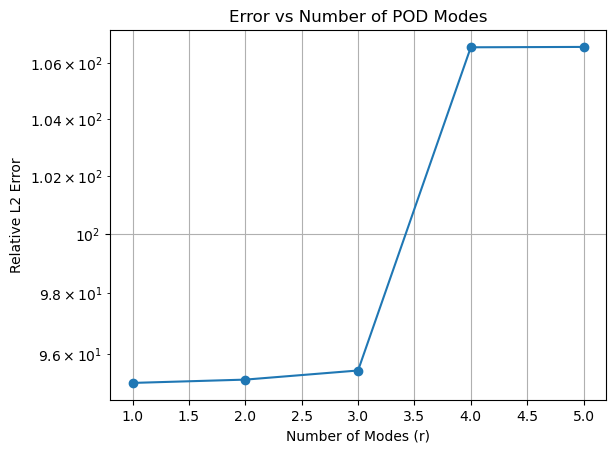

In [48]:
error = np.zeros(5)
for r in range(1, 6):
    V_r = U[:, :r]
    A_red = build_reduced_stiffness(A_test, V_r)
    b_red = build_reduced_load(b_test, V_r)
    u_red = np.linalg.solve(A_red, b_red)
    u_approx = V_r.dot(u_red) + u_L_vect
    u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
    error[r-1] = error_L2(u_full_fenics, u_approx_fenics)
    print(f"Error with {r} modes: {error[r-1]:.4e}")
plt.figure()
plt.semilogy(range(1, 6), error, marker='o')
plt.xlabel('Number of Modes (r)')
plt.ylabel('Relative L2 Error')
plt.title('Error vs Number of POD Modes')
plt.grid()
plt.show()